In [ ]:
import os
import platform
import shutil
import subprocess
import sys

import qiskit
from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import array_to_latex, plot_histogram, plot_state_qsphere
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

import matplotlib.pyplot as plt


token = "..."
instance = "..."  # looks like "crn:v1:bluemix:public:quantum-computing:..."

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=token,
    instance=instance,
    overwrite=True,
    set_as_default=True,
)

# Verify
service = QiskitRuntimeService()
backends = service.backends(use_fractional_gates=True)
print(f"Account OK. {len(backends)} backend(s) available:")
for b in backends[:5]:
    print(f"  {b.name} ({b.num_qubits} qubits)")

# qiskit-qaoa-knapsack-domi

Solving the 0/1 knapsack problem by **digitized quantum annealing** on IBM
Quantum hardware. There is no classical optimizer — the cost function
parameters are found in advance by statevector-simulating the very circuit that
will then run.

Only `values`, `weights` and `capacity` are passed into the module. **N is
derived from their count**, and the rest of the parameters (ALPHA, LAM1, LAM2,
STEPS, T, recommended SHOTS) are determined by `tune_penalties()`.

## Installation

```bash
pip install qiskit-qaoa-knapsack-domi          # core
pip install "qiskit-qaoa-knapsack-domi[plots]" # + matplotlib for the plots
pip install "qiskit-qaoa-knapsack-domi[all]"   # + mapomatic
```

To run on real hardware you need to save your account once:

```python
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="...",       # from quantum.ibm.com
    instance="crn:v1:bluemix:public:quantum-computing:...",
    overwrite=True, set_as_default=True,
)
```

## Quick start

```python
from qiskit_qaoa_knapsack_domi import KnapsackProblem, RunConfig, solve

problem = KnapsackProblem.random(15, seed=38)      # or your own values/weights
session = solve(problem, config=RunConfig(dry_run=True))

print(session.result.value, "/", session.result.optimum)
```

## Defining the instance

The inputs are always just `values`, `weights` and `capacity`. **N is derived
from `len(values)`** and is never given separately.

### Your own numbers

```python
problem = KnapsackProblem(
    values=[10, 20, 30, 40],
    weights=[5, 4, 6, 3],
    capacity=10,          # when omitted, sum(weights) // 3 is used
)
```

### Exactly as in the notebook

This notebook code:

```python
import random

random.seed(38)
N = 15
values   = [random.randint(5, 60) for _ in range(N)]
weights  = [random.randint(1, 20) for _ in range(N)]
CAPACITY = sum(weights) // 3
```

can be carried over in two ways. Either literally, if you want to keep the
generation under your own control:

```python
import random
from qiskit_qaoa_knapsack_domi import KnapsackProblem

random.seed(38)
N = 15
values   = [random.randint(5, 60) for _ in range(N)]
weights  = [random.randint(1, 20) for _ in range(N)]
CAPACITY = sum(weights) // 3

problem = KnapsackProblem(values, weights, CAPACITY)
problem.log()
# values : [45, 31, 32, 53, 51, 11, 9, 28, 49, 34, 28, 7, 43, 47, 15]
# weights: [19, 12, 11, 9, 11, 20, 10, 16, 19, 13, 8, 20, 3, 17, 16]
# capacity: 68
```

Or in short via `random()`, which gives a **bit-for-bit identical instance** —
it generates the same sequence with the same generator:

```python
problem = KnapsackProblem.random(15, seed=38)
```

### Setting the capacity by hand

The capacity does not have to be a third of the total weight. It can be given
directly:

```python
problem = KnapsackProblem.random(15, seed=38, capacity=100)        # exact value
problem = KnapsackProblem.random(15, seed=38, capacity_divisor=4)  # a quarter
```

The same applies to `KnapsackProblem(...)` — `capacity` is the third positional
argument, and `capacity_divisor` is used only when you omit it:

```python
KnapsackProblem(values, weights, 100)                      # capacity 100
KnapsackProblem(values, weights)                           # sum(weights) // 3
KnapsackProblem(values, weights, capacity_divisor=4)       # sum(weights) // 4
```

The capacity must be positive and smaller than the total weight; otherwise
everything would fit and the instance would be trivial.

### Different random ranges

```python
problem = KnapsackProblem.random(
    20, seed=7,
    value_range=(5, 60),      # both bounds inclusive
    weight_range=(1, 20),
    capacity=120,
)
```

From the command line:

```bash
qiskit-qaoa-knapsack-domi --n 15 --seed 38 --capacity 100
qiskit-qaoa-knapsack-domi --values 10,20,30 --weights 5,4,6 --capacity 9
```

## Settings (`RunConfig`)

The equivalent of the notebook's SETTINGS block. Original names in comments:

```python
from qiskit_qaoa_knapsack_domi import RunConfig, PlotConfig

cfg = RunConfig(
    dry_run=False,          # DRY_RUN: True = local fake backend (free)
    opt_level=3,            # OPT_LEVEL: transpiler aggressiveness
    num_transpiles=10,      # NUM_TRANSPILES: how many seeds to score
    use_mapomatic=False,    # USE_MAPOMATIC
    make_plots=True,        # MAKE_PLOTS: layout + result plots
    draw_circuit=True,      # DRAW_CIRCUIT: circuit diagrams
    fold=100,               # FOLD: gates per row (-1 = one row)
    layout_view="physical", # LAYOUT_VIEW: "physical" | "virtual"
    prune_keep=0.5,         # PRUNE_KEEP: fraction of ZZ couplings kept
    shots=300_000,          # SHOTS; "auto" = take tune_penalties' recommendation
    plots=PlotConfig(save_dir="out"),   # where to save the PNGs
)
```

There is **no** `N` in `RunConfig` — it comes from `len(problem.values)`.

## Step by step

`solve()` is only a wrapper; every step can be called on its own:

```python
from qiskit_qaoa_knapsack_domi import (
    KnapsackProblem, RunConfig, PlotConfig, tune_penalties,
    build_annealing_circuit, select_backend, transpile_best, run_circuit,
    best_feasible, build_distribution, plot_bitstrings, plot_tail,
)

problem = KnapsackProblem.random(15, seed=38)
cfg = RunConfig(
    dry_run=True,
    prune_keep=0.5,
    draw_circuit=True,               # logical and ISA circuit diagrams
    make_plots=True,                 # coupling map
    plots=PlotConfig(save_dir="out"),
)

# 1) penalties: ALPHA, LAM1, LAM2, STEPS, T + recommended SHOTS
pen = tune_penalties(
    problem,
    schedule_grid=[(3, 6.0), (5, 10.0), (7, 15.0)],
    max_rzz=500,
    alpha_out=2.0,
    l1_range=(2.0, 25.0),     # None = automatic window around the LP dual
    l2_range=(0.1, 5.0),
)
ALPHA, LAM1, LAM2, STEPS, T = pen.as_tuple()

# 2) QUBO -> ZZ pruning -> Ising -> circuit
#    draws the circuit diagram itself when draw_circuit=True
qc, qubo, ising = build_annealing_circuit(problem, penalties=pen, config=cfg)

# 3) backend + noise-aware transpilation
#    draws the coupling map and ISA diagram per make_plots / draw_circuit
backend = select_backend(cfg, num_qubits=qubo.n)
tr = transpile_best(qc, backend, cfg, num_items=problem.n)

# 4) run
counts = run_circuit(tr.circuit, backend, cfg, pen)

# 5) results
sel, w, v = best_feasible(counts, problem)
dist = build_distribution(counts, problem, good=0.90)

# 6) result plots are called by hand; `plots=` is needed to save the PNGs
plot_bitstrings(dist, backend_name=backend.name, plots=cfg.plots)
plot_tail(dist, plots=cfg.plots)
```

### What gets drawn when

`draw_circuit` and `make_plots` behave the same in `solve()` and step by step:

| flag | what it draws | where |
|---|---|---|
| `draw_circuit` | logical circuit diagram | `build_annealing_circuit()` |
| `draw_circuit` | ISA circuit diagram (what runs on the chip) | `transpile_best()` |
| `make_plots` | coupling map with the used qubits highlighted | `transpile_best()` |

The result plots (`plot_bitstrings`, `plot_tail`) are drawn by `solve()` itself
when `make_plots=True`. Going step by step you call them yourself — and if you
also want them saved, pass `plots=cfg.plots`, otherwise they are only displayed.

## What `tune_penalties` does

It searches (LAM1, LAM2) pairs and (STEPS, T) schedules and picks the ones with
the highest P(optimum). Scoring is always a statevector simulation of the
circuit that will then run — no proxy quantity.

- **Hard condition**: pairs where the global minimum of the cost function is not
  the DP optimum are discarded. This is tested on a Pareto reduction, i.e. on a
  few hundred candidates instead of 2^N.
- **Coarse grid → refinement → final**: phases A/B run the cheapest schedule,
  and all schedules are tried only on the `n_final` best candidates.
- **LAM2 is traversed logarithmically** — the optimum often sits just above the
  validity floor, where a linear grid has no resolution.
- **`l1_range=None`** turns on an automatic window around the LP dual (the
  shadow price of capacity). Measured on N=8..15: the winning LAM1/ALPHA always
  fell within 1.09–1.38× the LP dual.
- **`gate_error=...`** scores P(opt) after the attenuation
  `exp(-gate_error * 2.9 * RZZ)`, so a depth the hardware cannot sustain is not
  selected.

It returns `Penalties`, which can also be indexed like a dictionary
(`pen["LAM1"]`), so code carried over from the notebook works unchanged.

The original slow `tune_penalties` from the notebook is not part of the package;
only the fast version (`tune_penalties2` in the notebook) remains, under the
name without the digit.

## Pruning the couplings

`PRUNE_KEEP` is the main lever on circuit depth — weak couplings cost just as
many two-qubit gates as strong ones. It can also be called on its own:

```python
from qiskit_qaoa_knapsack_domi import prune_couplings

quad = prune_couplings(raw_couplings, prune_keep=0.5)
# ZZ gates: stayed 53/105 (50%)
```

## Plots

Plotting is kept separate so the package can be used without matplotlib:

| function | what it does |
|---|---|
| `draw_circuit_diagram(qc, cfg)` | diagram of the logical or transpiled circuit |
| `plot_layout(isa, backend, cfg)` | coupling map with the used qubits highlighted |
| `plot_bitstrings(dist)` | top-K bitstrings; red = optimum, blue = within 10 % |
| `plot_tail(dist)` | P(sample at least this good) vs uniform random |
| `plot_results(counts, problem)` | both at once from ready-made counts |

### How many bitstrings to plot

`plot_bitstrings` draws the K most probable bitstrings, 300 by default. Two
ways to change that — a per-call argument, or the config:

```python
# per call; overrides the config without modifying it
plot_bitstrings(dist, backend_name=backend.name, top_k=50, plots=cfg.plots)

# or as a default for the whole run, including inside solve()
cfg = RunConfig(plots=PlotConfig(top_k=50, save_dir="out"))
```

`plot_results` takes `top_k` as well. Bitstrings that were never sampled are
dropped, so with `top_k=300` and only 80 distinct outcomes you get 80 bars.
The figure width scales with the number of bars (clamped between 14 and 50
inches), so large values produce very wide images — for a readable chart 30–100
usually works better than the default.

## Command line

```bash
qiskit-qaoa-knapsack-domi --n 15 --seed 38 --dry-run --no-draw
qiskit-qaoa-knapsack-domi --values 10,20,30 --weights 5,4,6 --capacity 9 \
    --shots auto --save-dir out --json result.json
```

## Notes on the limits

- `tune_penalties` and the ground-state check walk all 2^N states. Above ~20
  qubits this stops paying off; the check is skipped automatically above
  `max_exact_n` (24 by default).
- The number of RZZ per layer is N(N−1)/2. At N=15 with STEPS=3 that is 315
  logical RZZ before transpilation even starts — hence `max_rzz` and
  `prune_keep`.
- Above `max_twoq_warn` (3000) two-qubit gates a warning is printed; by then the
  result tends to be mostly noise.

## Publishing to PyPI

```bash
pip install build twine
python -m build          # creates dist/*.whl and dist/*.tar.gz
python -m twine check dist/*
python -m twine upload --repository testpypi dist/*   # TestPyPI first
python -m twine upload dist/*
```

Before uploading, set the real repository URL and author name in
`pyproject.toml`.

## Development

```bash
pip install -e ".[dev]"
pytest -q
ruff check src tests examples
```


values : [45, 31, 32, 53, 51, 11, 9, 28, 49, 34]
weights: [12, 2, 20, 6, 19, 12, 11, 9, 11, 20]
capacity: 40
TUNE  N=10  capacity=40  DP optimum=206  uniform=0.0977 %
      1461 points simulated, 109 candidates in the Pareto reduction
     LAM1    LAM2 STEPS      T    P(opt)  x uniform  rank  P(feas)
     5.80   0.087     3    6.0    6.699%      68.6x     1    53.6%
     5.70   0.087     3    6.0    6.694%      68.5x     1    52.9%
     5.90   0.087     3    6.0    6.678%      68.4x     1    54.3%
     5.60   0.087     3    6.0    6.662%      68.2x     1    52.2%
     6.00   0.087     3    6.0    6.633%      67.9x     1    54.9%
     5.50   0.087     3    6.0    6.601%      67.6x     1    51.6%
     6.10   0.087     3    6.0    6.566%      67.2x     1    55.6%
     5.40   0.087     3    6.0    6.512%      66.7x     1    51.0%

  ==> ALPHA = 2.0   LAM1 = 5.80   LAM2 = 0.087   STEPS = 3   T = 6.0
      P(opt) = 6.699 % = 68.6x uniform, rank 1, 135 logical RZZ
      plateau: LAM1 5.40-6.1

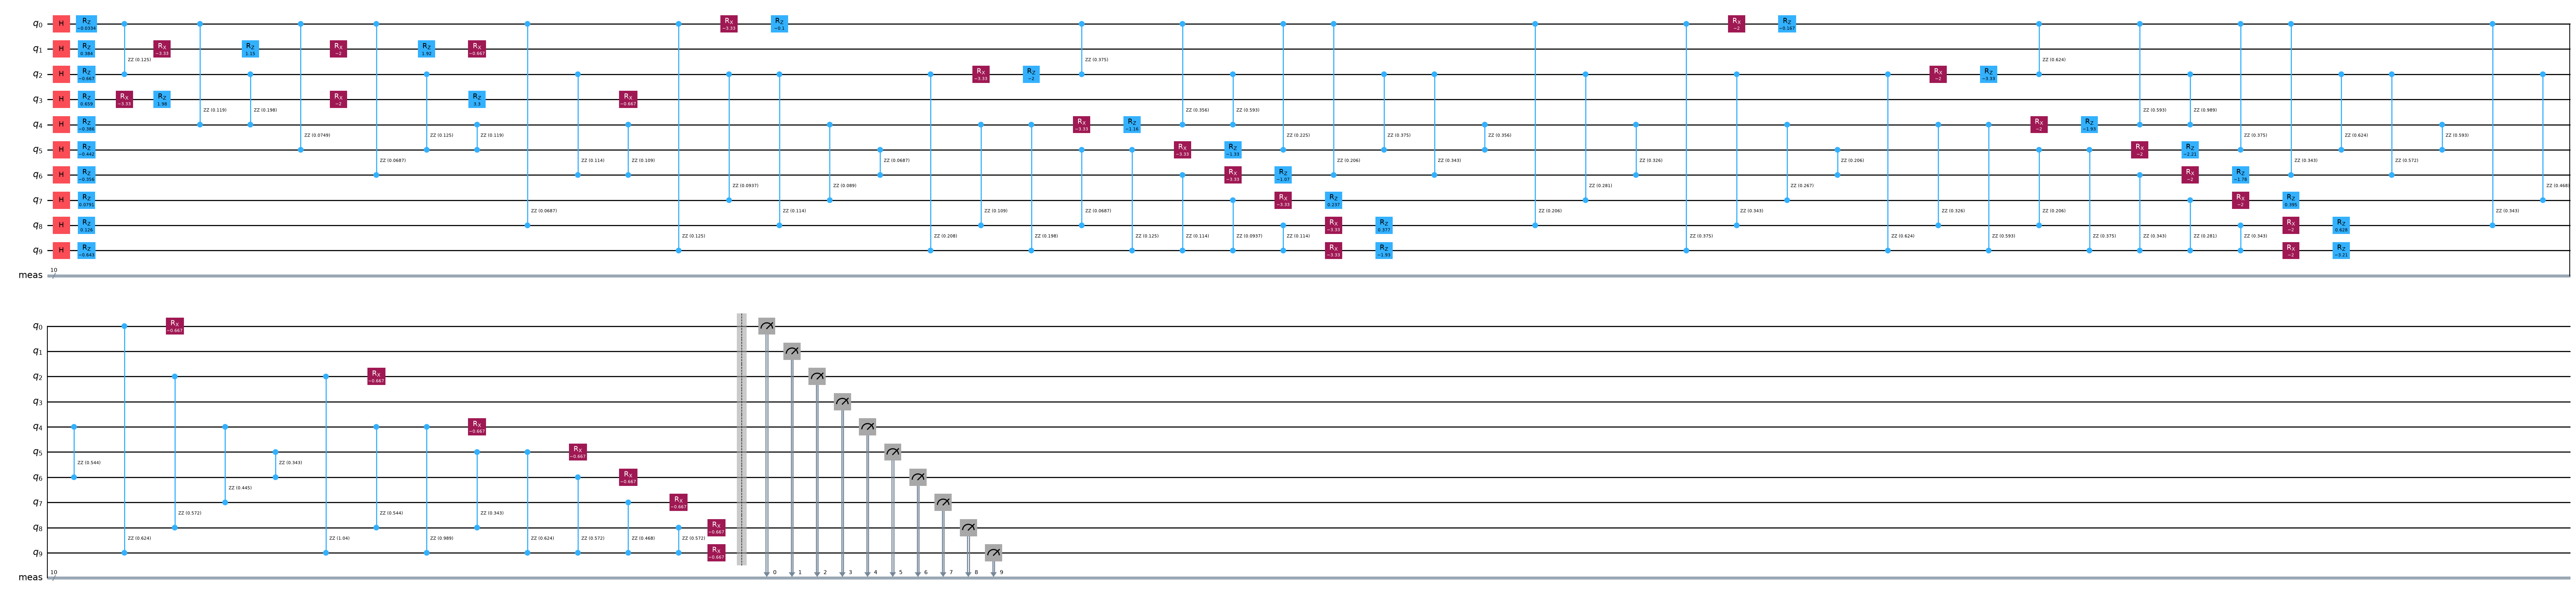

[DRY_RUN] fake backend: fake_sherbrooke (127 qubits)

 TRANSPILATION  (noise-aware layout selection)

[A] Seed scan (10 transpiles), top 5 by error:
     rank    err_sum     2q   depth  seed
        1     1.4280    265     735     2
        2     1.4811    276     802     1
        3     1.4821    275     770     6
        4     1.4834    275     787     4
        5     1.5741    256     726     7
     best seed error_sum = 1.4280  (worst = 1.8769, i.e. 24% lower)

----------------------------------------------------------------
 method         err_sum  2q gates   depth
----------------------------------------------------------------
 seed-scan       1.4280       265     735
----------------------------------------------------------------
 chosen: seed-scan
 physical qubits used (8): [40, 41, 53, 58, 59, 60, 61, 62]

 logical -> physical qubit map:
   logical  role       physical
         0  item 0           40
         1  item 1           74
         2  item 2           41
         3 

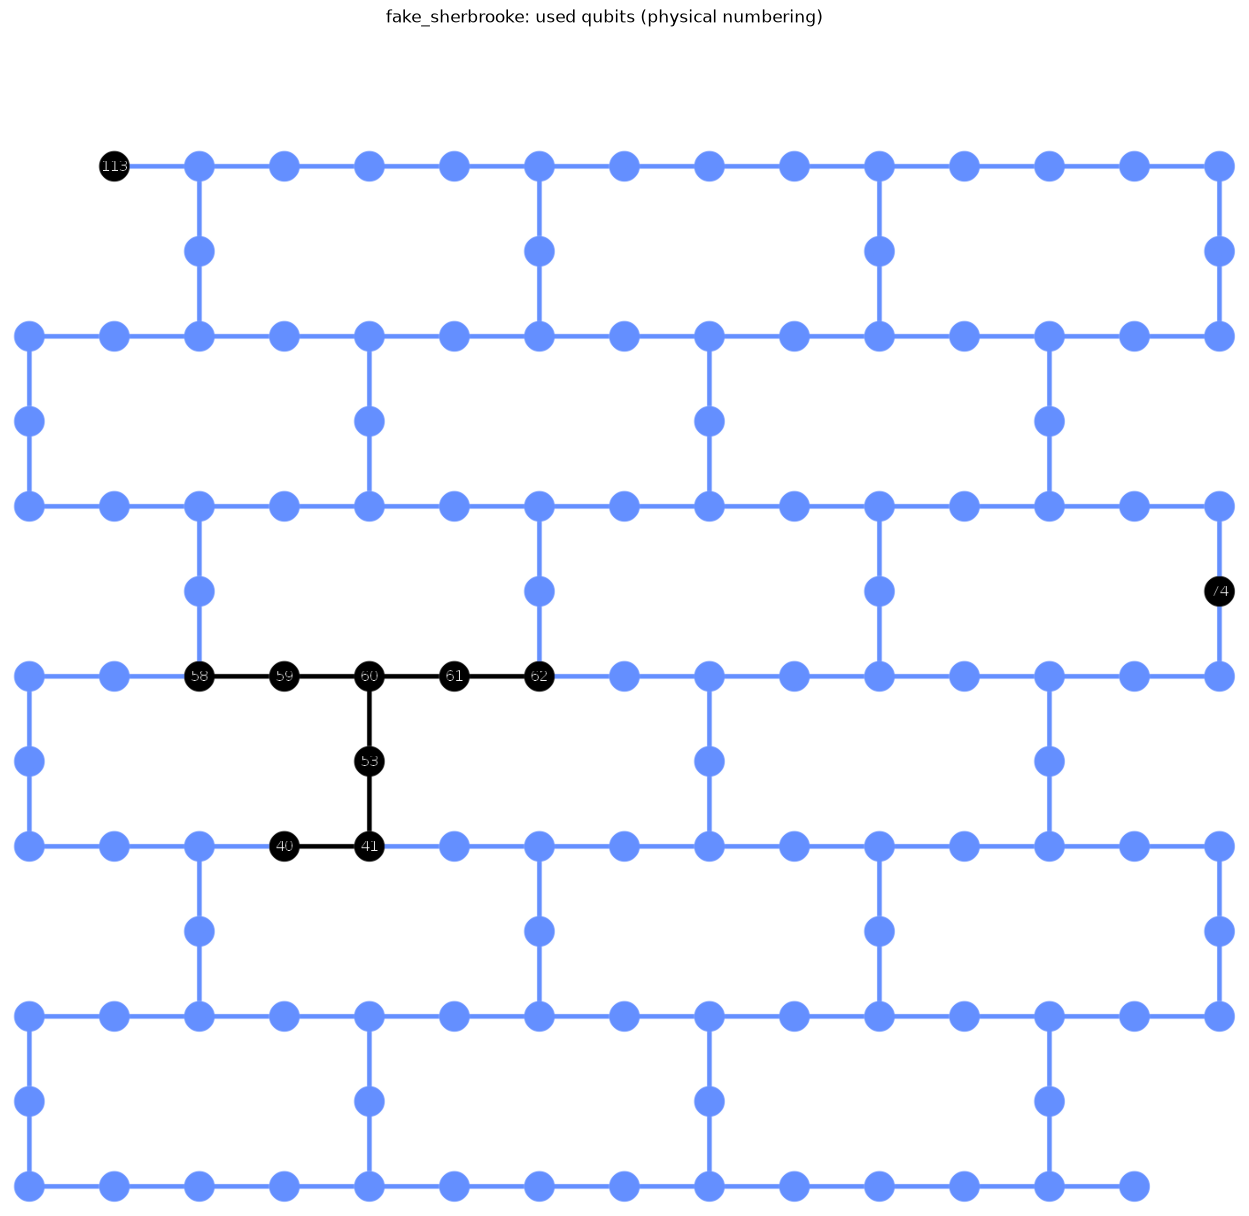

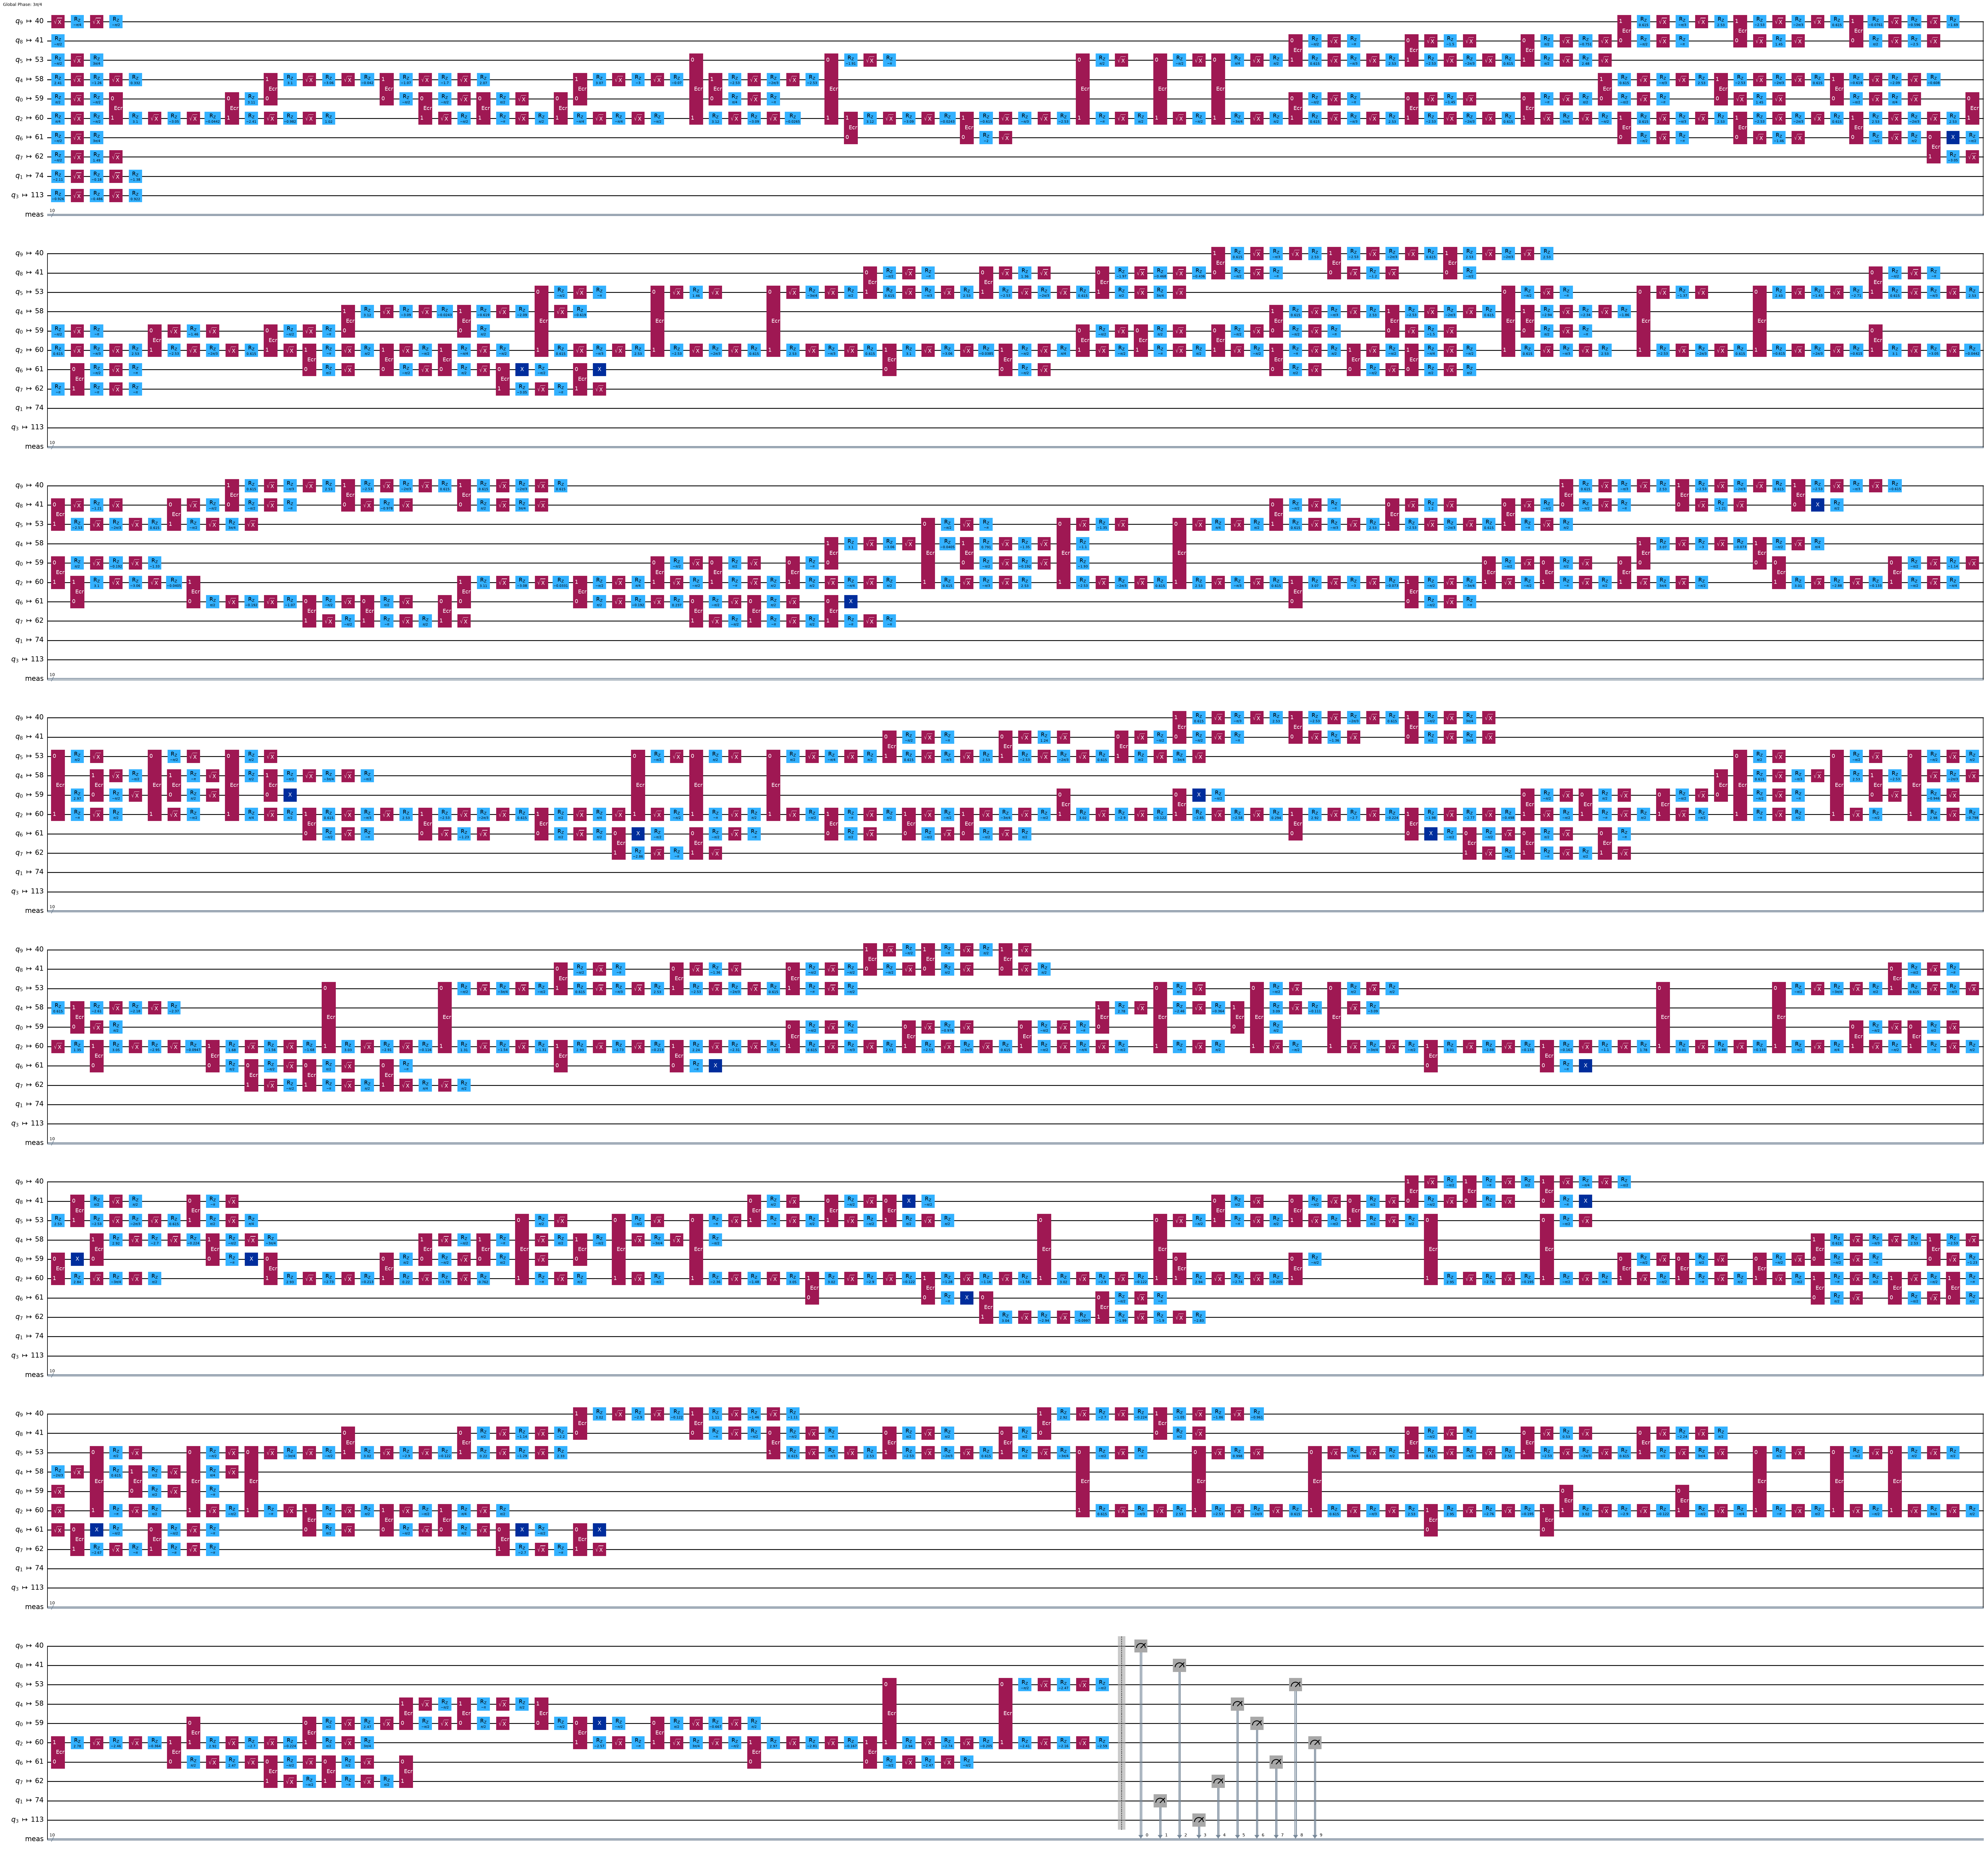

OrderedDict({'rz': 917, 'sx': 654, 'ecr': 265, 'x': 20, 'measure': 10, 'barrier': 1})

Job ID: 210364f8-01a2-4d11-8551-a766bbb9ff9e


B:\python\myqiskit\Lib\site-packages\qiskit_ibm_runtime\fake_provider\local_service.py:274: UserWarning: Options {'dynamical_decoupling': {'enable': True, 'sequence_type': 'XY4'}, 'twirling': {'enable_gates': True, 'enable_measure': True}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")



                    KNAPSACK  -  RESULT SUMMARY
 Backend : fake_sherbrooke          Logical qubits : 10
 Method  : digitized quantum annealing (no optimizer)
 Layout  : seed-scan   |   2q gates : 265
----------------------------------------------------------------
 Selected items
----------------------------------------------------------------
     Item    Value   Weight
   ------ -------- --------
        0       45       12
        1       31        2
        3       53        6
        7       28        9
        8       49       11
   ------ -------- --------
    TOTAL      206       40    (capacity 40)
----------------------------------------------------------------
 Solution quality
----------------------------------------------------------------
   Method                   Value   % of optimum
   ---------------------- ------- --------------
   Quantum (hardware)         206         100.0%
   Exact (dynamic prog.)      206              -
OPT = 206   optimal bitstrings: 1
P(feas

In [5]:
from qiskit_qaoa_knapsack_domi import (
    KnapsackProblem, RunConfig, PlotConfig, tune_penalties,
    build_annealing_circuit, select_backend, transpile_best, run_circuit,
    best_feasible, build_distribution, plot_bitstrings, plot_tail, build_result,
)


cfg = RunConfig(
    dry_run=True,          # DRY_RUN: True = local fake backend (free)
    opt_level=3,            # OPT_LEVEL: transpiler aggressiveness
    num_transpiles=10,      # NUM_TRANSPILES: how many seeds to score
    use_mapomatic=False,    # USE_MAPOMATIC
    make_plots=True,        # MAKE_PLOTS: layout + result plots
    draw_circuit=True,      # DRAW_CIRCUIT: circuit diagrams
    fold=100,               # FOLD: gates per row (-1 = one row)
    layout_view="physical", # LAYOUT_VIEW: "physical" | "virtual"
    prune_keep=0.5,         # PRUNE_KEEP: fraction of ZZ couplings kept
    shots=30000,          # SHOTS; "auto" = take tune_penalties' recommendation
    plots=PlotConfig(save_dir="out"),   # where to save the PNGs
)

import random
from qiskit_qaoa_knapsack_domi import KnapsackProblem

random.seed(38)
N = 10
values   = [random.randint(5, 60) for _ in range(N)]
weights  = [random.randint(1, 20) for _ in range(N)]
CAPACITY = sum(weights) // 3

problem = KnapsackProblem(values, weights, CAPACITY)
problem.log()

# 1) penalties: ALPHA, LAM1, LAM2, STEPS, T + recommended SHOTS
pen = tune_penalties(
    problem,
    schedule_grid=[(3, 6.0), (5, 10.0), (7, 15.0)],
    max_rzz=500,
    alpha_out=2.0,
    l1_range=(2.0, 25.0),     # None = automatic window around the LP dual
    l2_range=(0.1, 5.0),
)
ALPHA, LAM1, LAM2, STEPS, T = pen.as_tuple()

# 2) QUBO -> ZZ pruning -> Ising -> circuit
#    draws the circuit diagram itself when draw_circuit=True
qc, qubo, ising = build_annealing_circuit(problem, penalties=pen, config=cfg)

# 3) backend + noise-aware transpilation
#    draws the coupling map and ISA diagram per make_plots / draw_circuit
backend = select_backend(cfg, num_qubits=qubo.n)
tr = transpile_best(qc, backend, cfg, num_items=problem.n)

# 4) run
counts = run_circuit(tr.circuit, backend, cfg, pen)
result = build_result(counts, problem, backend=backend, transpiled=tr)
# 5) results
sel, w, v = best_feasible(counts, problem)
dist = build_distribution(counts, problem, good=0.90)



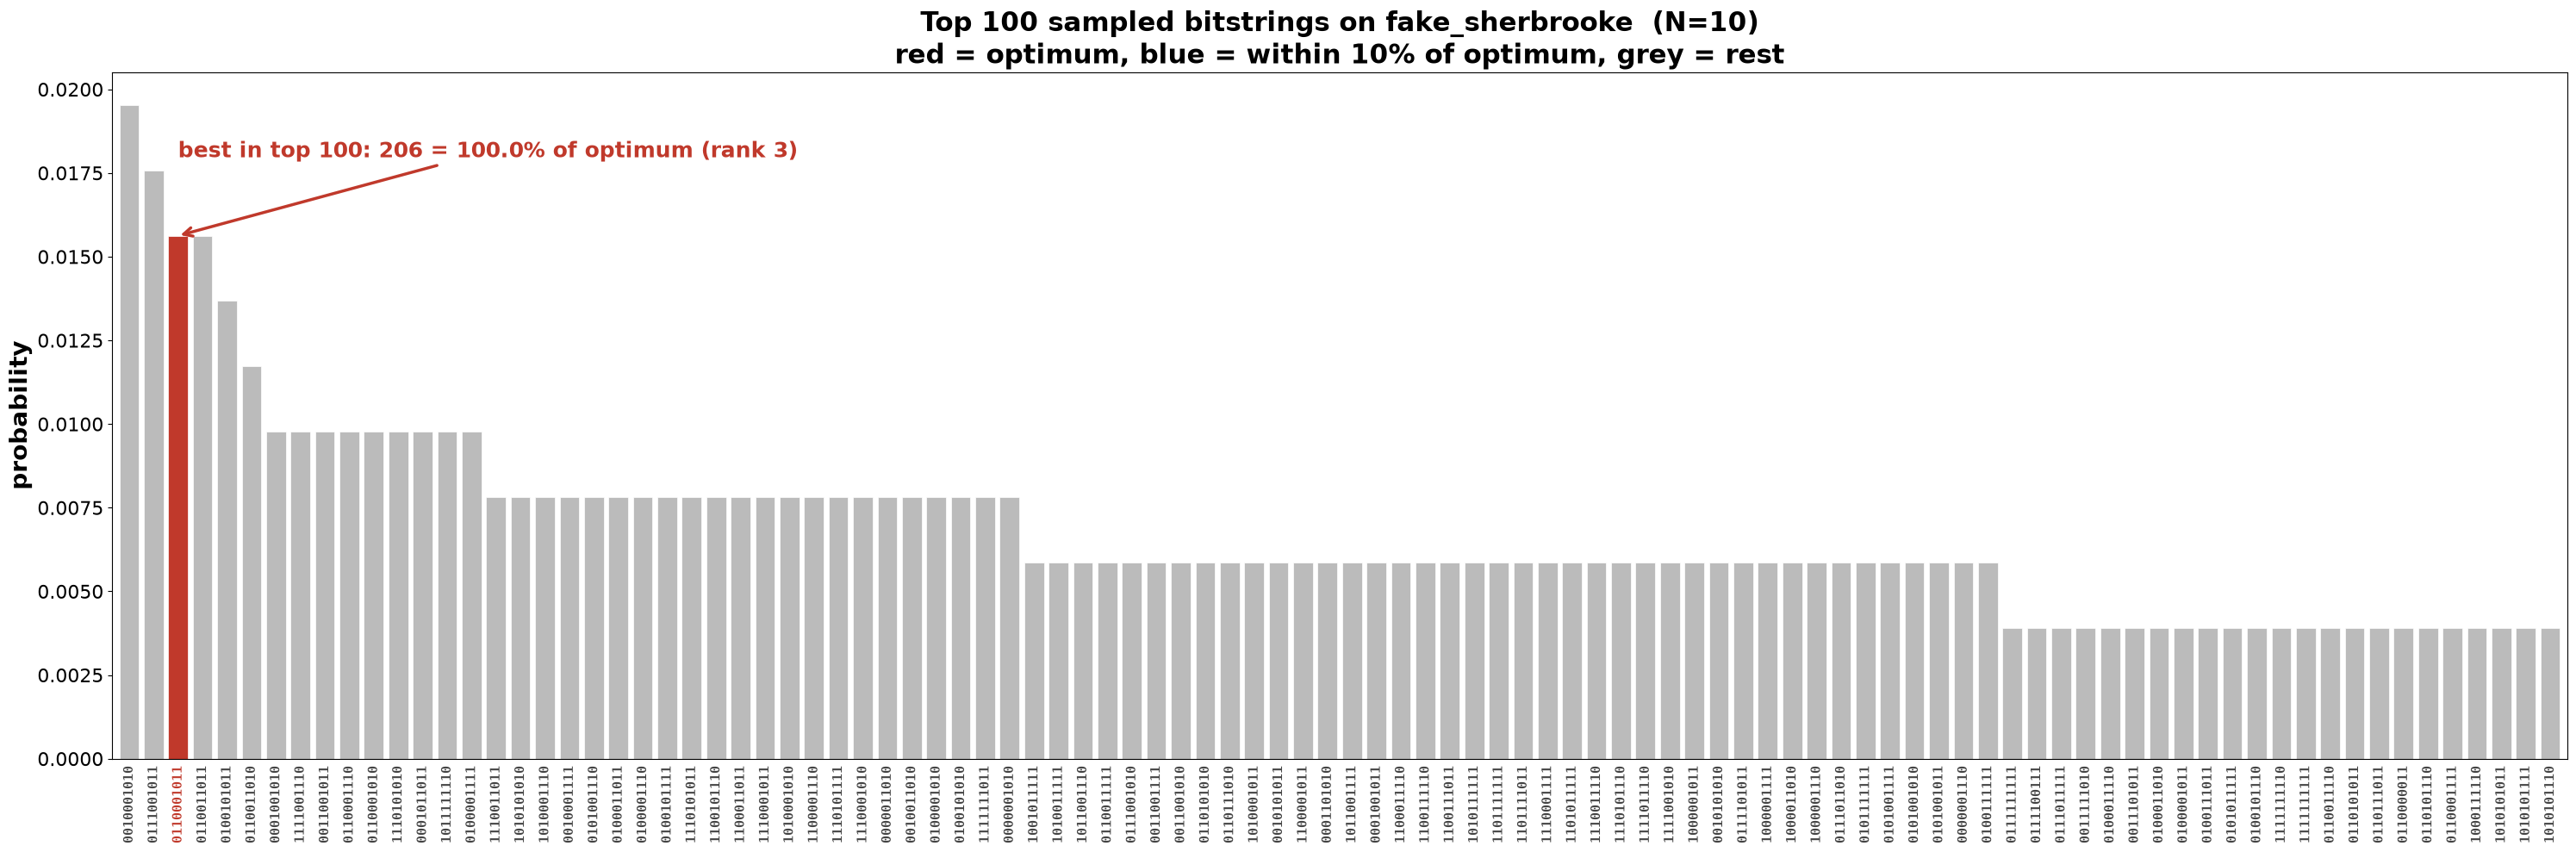

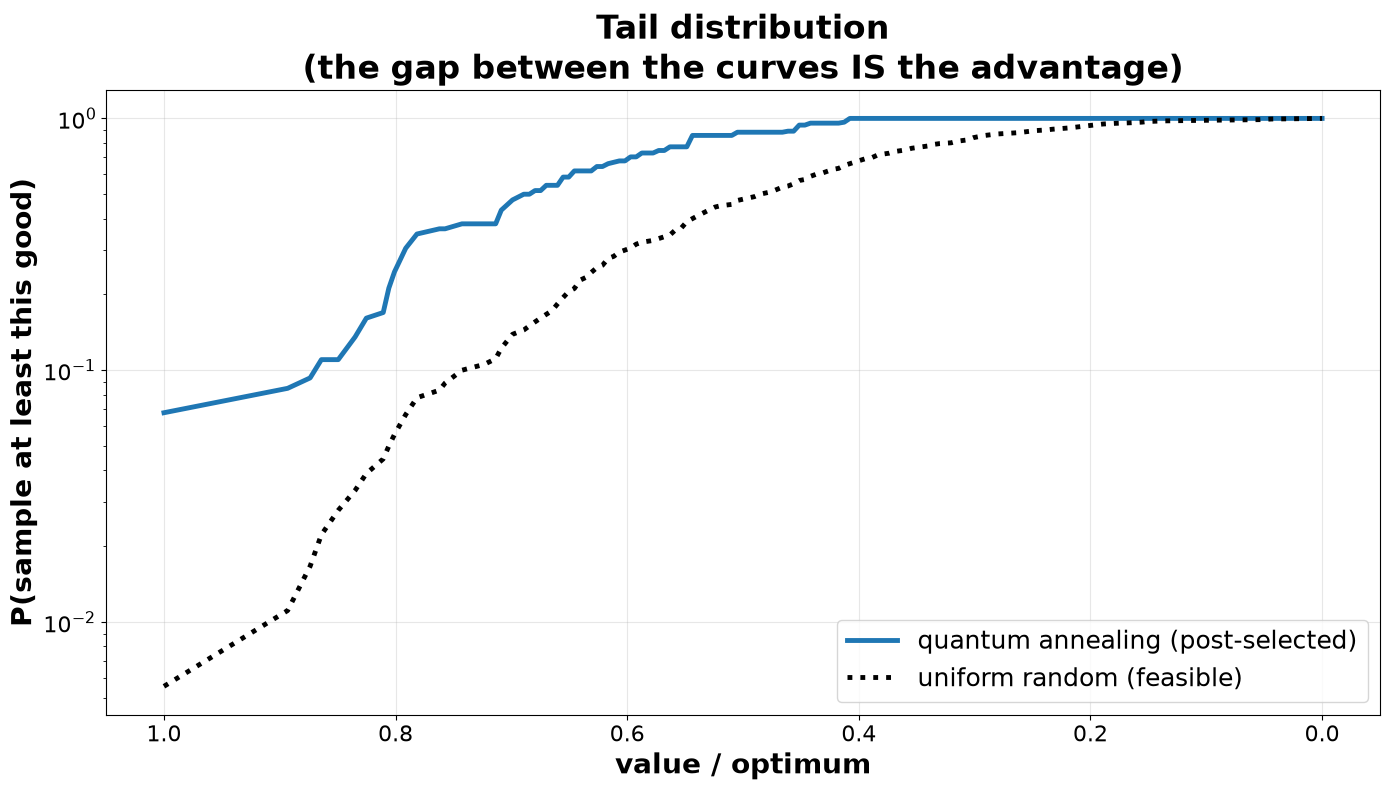

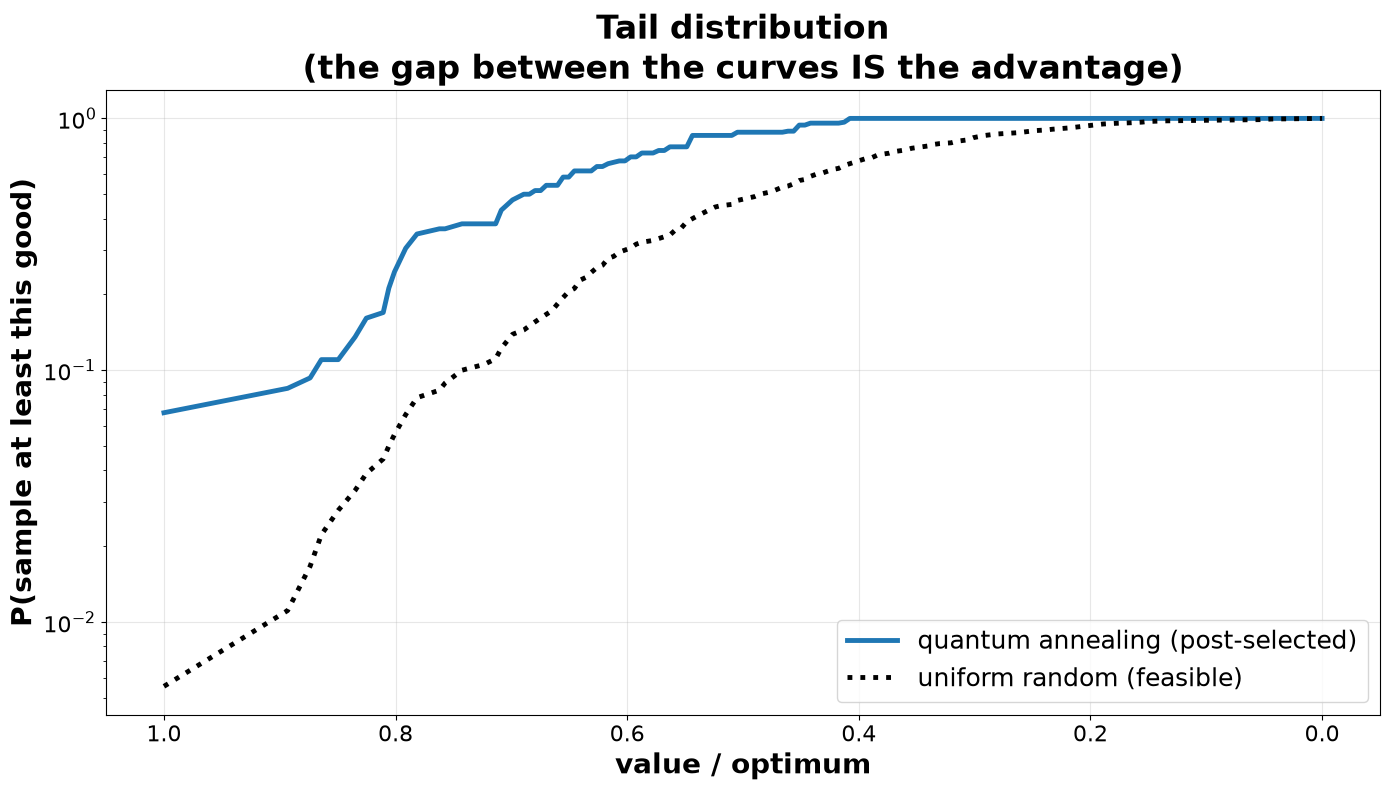

In [6]:
# 6) result plots are called by hand; `plots=` is needed to save the PNGs
plot_bitstrings(dist, backend_name=backend.name, top_k=100, plots=cfg.plots)
plot_tail(dist, plots=cfg.plots)

In [3]:
import qiskit_qaoa_knapsack_domi as m
print(m.__version__)

0.3.0
